In [1]:
import os, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import TimeSeriesSplit, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, accuracy_score, average_precision_score
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.calibration import calibration_curve

Matplotlib is building the font cache; this may take a moment.


In [2]:
# ── Plot style ──
plt.rcParams.update({
    "figure.dpi"       : 120,
    "figure.facecolor" : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "DejaVu Sans",
})
sns.set_palette("husl")

In [3]:
# ── Paths ──
DATA_PATH  = "../data/processed/azamgarh_weather_final.csv"
MODEL_DIR  = "../models/xgboost"
os.makedirs(MODEL_DIR,  exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print(f"   Model output → {MODEL_DIR}")

   Model output → ../models/xgboost


In [4]:
df = pd.read_csv(DATA_PATH, parse_dates=["valid_time"])
df = df.sort_values("valid_time").reset_index(drop=True)

print(f"Shape          : {df.shape}")
print(f"Date range     : {df['valid_time'].min()} → {df['valid_time'].max()}")
print(f"Missing values :\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nDtypes:\n{df.dtypes}")
df.head()


Shape          : (43800, 22)
Date range     : 2021-01-02 05:30:00 → 2026-01-01 04:30:00
Missing values :
Series([], dtype: int64)

Dtypes:
valid_time            datetime64[us]
temperature                  float64
surface_pressure             float64
total_cloud_cover            float64
low_cloud_cover              float64
medium_cloud_cover           float64
high_cloud_cover             float64
precipitation                float64
humidity                     float64
wind_speed                   float64
hour                           int64
day                            int64
month                          int64
day_of_week                    int64
temp_lag_1                   float64
temp_lag_24                  float64
temp_rolling_6               float64
hour_sin                     float64
hour_cos                     float64
month_sin                    float64
month_cos                    float64
rain_tomorrow                  int64
dtype: object


,valid_time,temperature,surface_pressure,total_cloud_cover,low_cloud_cover,medium_cloud_cover,high_cloud_cover,precipitation,humidity,wind_speed,...,month,day_of_week,temp_lag_1,temp_lag_24,temp_rolling_6,hour_sin,hour_cos,month_sin,month_cos,rain_tomorrow
0,2021-01-02 05:30:00,7.3191,1007.57,0.586762,0.0,0.0,0.586762,0.0,86.73,0.9666,...,1,5,6.3538,6.6150,7.3103,0.965926,0.258819,0.5,0.866025,0
1,2021-01-02 06:30:00,7.8957,1008.60,0.755707,0.0,0.0,0.755707,0.0,83.78,0.9099,...,1,5,7.3191,6.1304,7.1736,1.000000,0.000000,0.5,0.866025,0
2,2021-01-02 07:30:00,8.7751,1009.58,0.867371,0.0,0.0,0.867371,0.0,81.91,0.7471,...,1,5,7.8957,6.9004,7.3546,0.965926,-0.258819,0.5,0.866025,0
3,2021-01-02 08:30:00,9.1403,1010.22,0.919342,0.0,0.0,0.919342,0.0,81.13,0.4304,...,1,5,8.7751,7.8723,7.6300,0.866025,-0.500000,0.5,0.866025,0
4,2021-01-02 09:30:00,11.5016,1010.77,0.910004,0.0,0.0,0.910004,0.0,77.41,0.1777,...,1,5,9.1403,10.9252,8.4976,0.707107,-0.707107,0.5,0.866025,0


── Target Distribution ──
  No Rain (0): 30824  (70.4%)
  Rain    (1): 12976  (29.6%)
  Imbalance ratio: 2.4:1


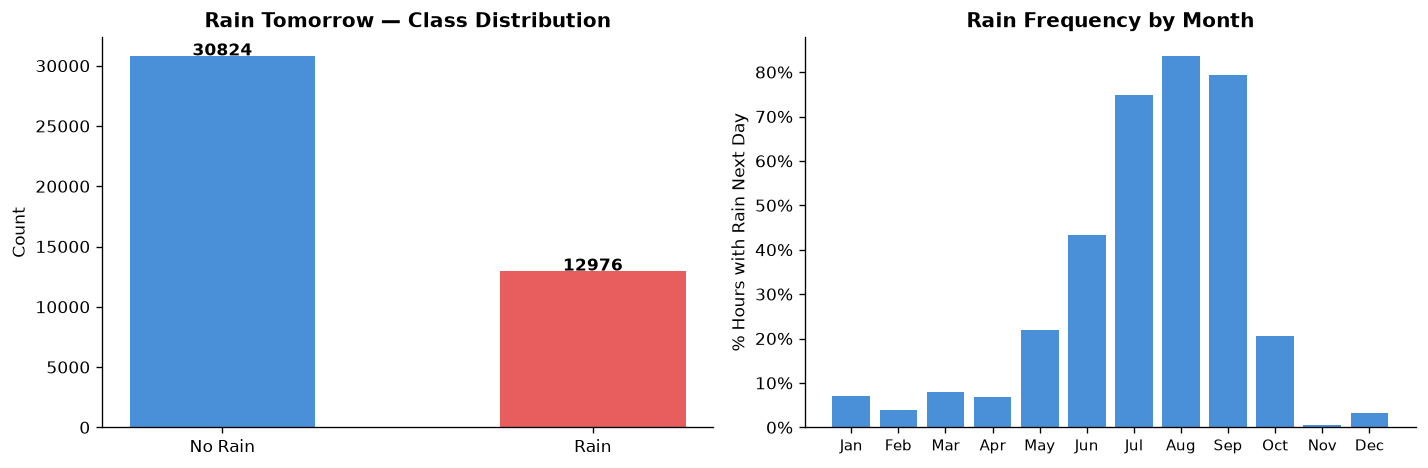

In [ ]:

rain_counts = df["rain_tomorrow"].value_counts()
rain_pct    = df["rain_tomorrow"].value_counts(normalize=True) * 100

print("── Target Distribution ──")
print(f"  No Rain (0): {rain_counts[0]:>5}  ({rain_pct[0]:.1f}%)")
print(f"  Rain    (1): {rain_counts[1]:>5}  ({rain_pct[1]:.1f}%)")
print(f"  Imbalance ratio: {rain_counts[0]/rain_counts[1]:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(["No Rain", "Rain"], rain_counts.values, color=["#4A90D9", "#E85D5D"], width=0.5)
axes[0].set_title("Rain Tomorrow — Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(rain_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

# Monthly rain frequency
monthly = df.groupby("month")["rain_tomorrow"].mean() * 100
months  = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[1].bar(range(1,13), monthly.values, color="#4A90D9")
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(months, fontsize=9)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("Rain Frequency by Month", fontweight="bold")
axes[1].set_ylabel("% Hours with Rain Next Day")

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/class_distribution.png", bbox_inches="tight")
plt.show()


In [6]:
FEATURES = [
    "temperature", "surface_pressure", "total_cloud_cover",
    "low_cloud_cover", "medium_cloud_cover", "high_cloud_cover",
    "precipitation","humidity", "wind_speed", "temp_rolling_6",
    "temp_lag_1", "temp_lag_24", "month",
]
TARGET = "rain_tomorrow"

# Summary stats split by target
print("── Feature Stats: No Rain vs Rain ──")
df.groupby(TARGET)[FEATURES[:8]].mean().T.rename(columns={0:"No Rain", 1:"Rain"}).round(2)


── Feature Stats: No Rain vs Rain ──


rain_tomorrow,No Rain,Rain
temperature,24.49,29.04
surface_pressure,1001.04,993.82
total_cloud_cover,0.23,0.80
low_cloud_cover,0.06,0.23
medium_cloud_cover,0.07,0.37
high_cloud_cover,0.14,0.69
precipitation,0.01,0.42
humidity,65.41,82.03


In [7]:
X = df[FEATURES]
y = df[TARGET].astype(int)

# ── Time-based split — NO shuffle (prevents data leakage) ──
split_idx = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

train_dates = df["valid_time"].iloc[:split_idx]
test_dates  = df["valid_time"].iloc[split_idx:]

print(f"\nTrain set : {len(X_train):,} rows  ({train_dates.min().date()} → {train_dates.max().date()})")
print(f"Test  set : {len(X_test):,}  rows  ({test_dates.min().date()}  → {test_dates.max().date()})")

# Class imbalance — handle via sample weights
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
print(f"\nSample weight range: [{sample_weights.min():.3f}, {sample_weights.max():.3f}]")



Train set : 35,040 rows  (2021-01-02 → 2025-01-01)
Test  set : 8,760  rows  (2025-01-01  → 2026-01-01)

Sample weight range: [0.705, 1.717]


In [8]:
# ── TimeSeriesSplit CV (5 folds) ──
tscv = TimeSeriesSplit(n_splits=5)

cv_scores = {"accuracy": [], "f1": [], "roc_auc": []}

print("── Time-Series Cross Validation ──")
print(f"{'Fold':<6} {'Train':>8} {'Val':>8} {'Accuracy':>10} {'F1':>8} {'ROC-AUC':>10}")
print("─" * 55)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    sw = compute_sample_weight("balanced", y=ytr)

    m = XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1
    )
    m.fit(Xtr, ytr, sample_weight=sw, verbose=False)
    yp = m.predict(Xval)
    ypp = m.predict_proba(Xval)[:, 1]

    acc = accuracy_score(yval, yp)
    f1  = f1_score(yval, yp, zero_division=0)
    auc = roc_auc_score(yval, ypp)

    cv_scores["accuracy"].append(acc)
    cv_scores["f1"].append(f1)
    cv_scores["roc_auc"].append(auc)
    print(f"{fold:<6} {len(Xtr):>8,} {len(Xval):>8,} {acc:>10.4f} {f1:>8.4f} {auc:>10.4f}")

print("─" * 55)
print(f"{'Mean':<6} {'':>8} {'':>8} {np.mean(cv_scores['accuracy']):>10.4f} "
      f"{np.mean(cv_scores['f1']):>8.4f} {np.mean(cv_scores['roc_auc']):>10.4f}")
print(f"{'Std':<6} {'':>8} {'':>8} {np.std(cv_scores['accuracy']):>10.4f} "
      f"{np.std(cv_scores['f1']):>8.4f} {np.std(cv_scores['roc_auc']):>10.4f}")


── Time-Series Cross Validation ──
Fold      Train      Val   Accuracy       F1    ROC-AUC
───────────────────────────────────────────────────────
1         5,840    5,840     0.8906   0.7010     0.8038
2        11,680    5,840     0.8014   0.7779     0.9328
3        17,520    5,840     0.8829   0.8015     0.9406
4        23,360    5,840     0.9315   0.7932     0.9509
5        29,200    5,840     0.8663   0.8352     0.9423
───────────────────────────────────────────────────────
Mean                         0.8745   0.7818     0.9141
Std                          0.0424   0.0445     0.0554


In [9]:
# ── Final model — train on full training set ──
model = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    use_label_encoder= False,
    eval_metric      = "logloss",
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
    early_stopping_rounds = 20,
)

print("Training final model...")
model.fit(
    X_train, y_train,
    sample_weight = sample_weights,
    eval_set      = [(X_test, y_test)],
    verbose       = 50,
)
print(f"\n✅ Best iteration: {model.best_iteration}")


Training final model...
[0]	validation_0-logloss:0.66056
[50]	validation_0-logloss:0.27010
[100]	validation_0-logloss:0.25342
[150]	validation_0-logloss:0.25333
[152]	validation_0-logloss:0.25345

✅ Best iteration: 132


In [10]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
ap  = average_precision_score(y_test, y_pred_prob)

print("═" * 45)
print("  FINAL TEST SET RESULTS")
print("═" * 45)
print(f"  Accuracy          : {acc:.4f}")
print(f"  F1 Score          : {f1:.4f}")
print(f"  ROC-AUC           : {auc:.4f}")
print(f"  Avg Precision     : {ap:.4f}")
print("═" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Rain", "Rain"]))


═════════════════════════════════════════════
  FINAL TEST SET RESULTS
═════════════════════════════════════════════
  Accuracy          : 0.8912
  F1 Score          : 0.8414
  ROC-AUC           : 0.9646
  Avg Precision     : 0.9295
═════════════════════════════════════════════

Classification Report:
              precision    recall  f1-score   support

     No Rain       0.96      0.88      0.92      5985
        Rain       0.78      0.91      0.84      2775

    accuracy                           0.89      8760
   macro avg       0.87      0.90      0.88      8760
weighted avg       0.90      0.89      0.89      8760



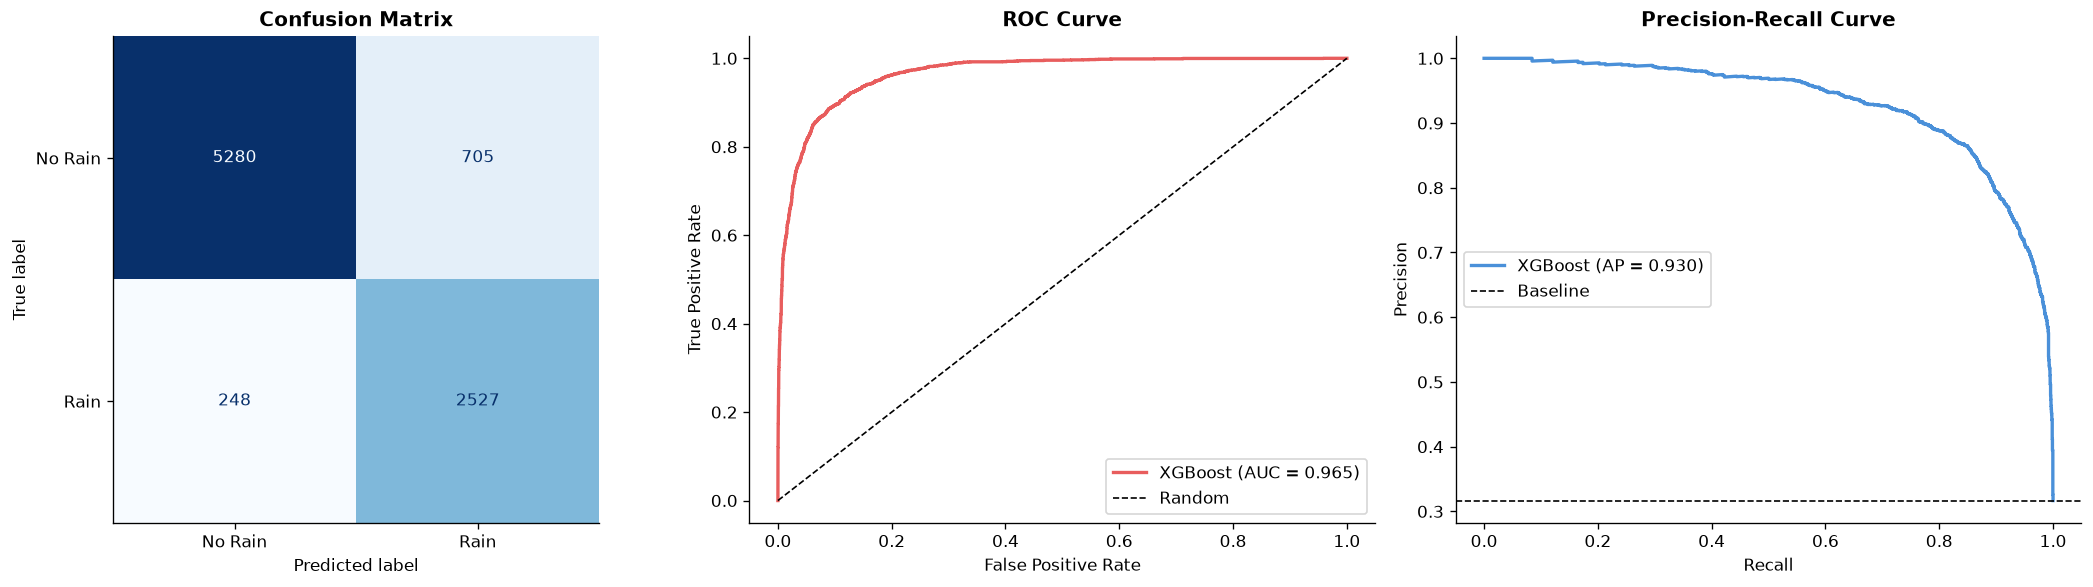

In [11]:
# ── Confusion Matrix + ROC + PR curves ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Rain", "Rain"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontweight="bold")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color="#E85D5D", lw=2, label=f"XGBoost (AUC = {auc:.3f})")
axes[1].plot([0,1], [0,1], "k--", lw=1, label="Random")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].legend()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_pred_prob)
axes[2].plot(rec, prec, color="#4A90D9", lw=2, label=f"XGBoost (AP = {ap:.3f})")
axes[2].axhline(y_test.mean(), color="k", linestyle="--", lw=1, label="Baseline")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve", fontweight="bold")
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/evaluation_curves.png", bbox_inches="tight")
plt.show()


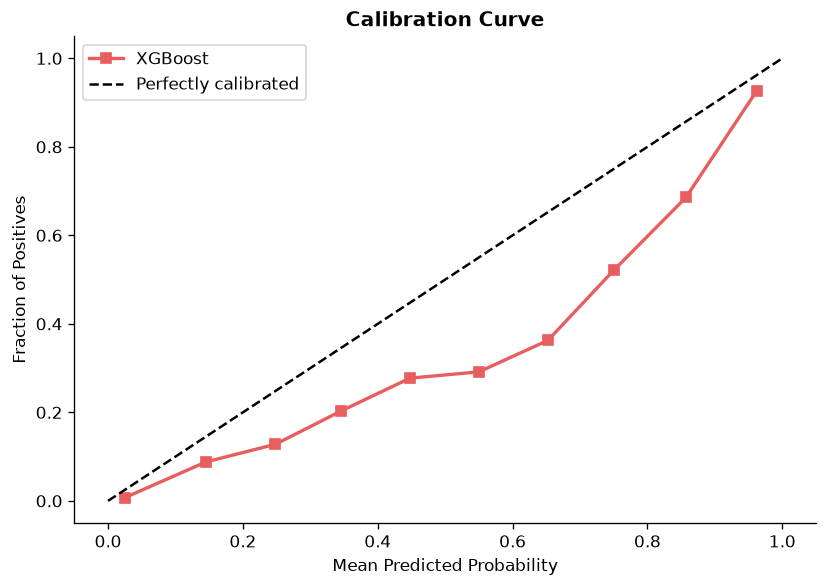

A well-calibrated model follows the diagonal line closely.


In [12]:
# ── Calibration curve (is the model's probability reliable?) ──
fig, ax = plt.subplots(figsize=(7, 5))
frac_pos, mean_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)
ax.plot(mean_pred, frac_pos, "s-", color="#E85D5D", label="XGBoost", lw=2)
ax.plot([0,1], [0,1], "k--", label="Perfectly calibrated")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Calibration Curve", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/calibration_curve.png", bbox_inches="tight")
plt.show()
print("A well-calibrated model follows the diagonal line closely.")


In [13]:
importance_gain   = model.get_booster().get_score(importance_type="gain")
importance_weight = model.get_booster().get_score(importance_type="weight")
importance_cover  = model.get_booster().get_score(importance_type="cover")

imp_df = pd.DataFrame({
    "Feature": FEATURES,
    "Gain"   : [importance_gain.get(f, 0)   for f in FEATURES],
    "Weight" : [importance_weight.get(f, 0) for f in FEATURES],
    "Cover"  : [importance_cover.get(f, 0)  for f in FEATURES],
}).sort_values("Gain", ascending=False).reset_index(drop=True)

print("── Feature Importance (by Gain) ──")
imp_df


── Feature Importance (by Gain) ──


,Feature,Gain,Weight,Cover
0,precipitation,423.539124,245.0,1339.117554
1,high_cloud_cover,232.928223,260.0,1077.375366
2,medium_cloud_cover,154.569595,288.0,923.041138
3,low_cloud_cover,68.345085,150.0,392.932373
4,total_cloud_cover,45.889919,205.0,694.413635
5,humidity,32.153160,561.0,575.115417
6,surface_pressure,24.588022,568.0,521.997253
7,month,19.774759,398.0,502.612549
8,wind_speed,14.143847,441.0,287.162476
9,temp_lag_1,13.986481,182.0,444.721619


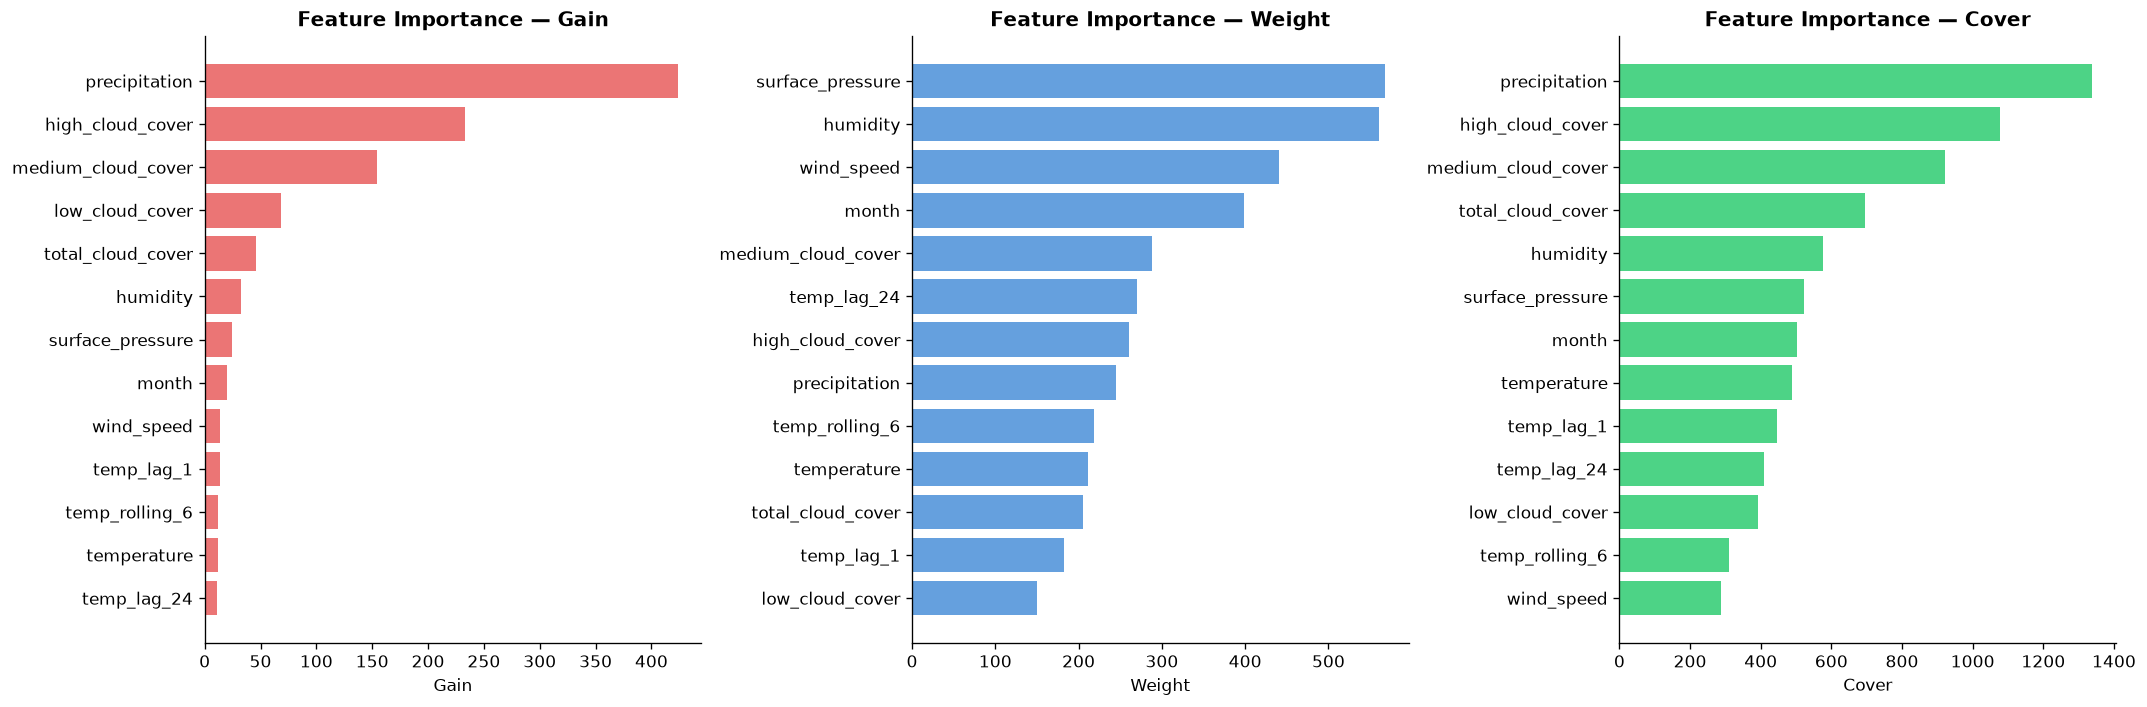

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ["Gain", "Weight", "Cover"]
colors  = ["#E85D5D", "#4A90D9", "#2ECC71"]

for ax, metric, color in zip(axes, metrics, colors):
    sorted_df = imp_df.sort_values(metric, ascending=True)
    ax.barh(sorted_df["Feature"], sorted_df[metric], color=color, alpha=0.85)
    ax.set_title(f"Feature Importance — {metric}", fontweight="bold")
    ax.set_xlabel(metric)

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/feature_importance.png", bbox_inches="tight")
plt.show()


In [15]:
thresholds = np.arange(0.1, 0.91, 0.05)
results = []

for thr in thresholds:
    yp = (y_pred_prob >= thr).astype(int)
    results.append({
        "threshold": round(thr, 2),
        "accuracy" : accuracy_score(y_test, yp),
        "f1"       : f1_score(y_test, yp, zero_division=0),
        "precision": confusion_matrix(y_test, yp)[1,1] /
                     (confusion_matrix(y_test, yp)[1,1] + confusion_matrix(y_test, yp)[0,1] + 1e-9),
        "recall"   : confusion_matrix(y_test, yp)[1,1] /
                     (confusion_matrix(y_test, yp)[1,1] + confusion_matrix(y_test, yp)[1,0] + 1e-9),
    })

thr_df = pd.DataFrame(results)
best_thr = thr_df.loc[thr_df["f1"].idxmax(), "threshold"]
print(f"Best threshold by F1 : {best_thr}")
print(thr_df.to_string(index=False))


Best threshold by F1 : 0.7
 threshold  accuracy       f1  precision   recall
      0.10  0.783219 0.742927   0.594970 0.988829
      0.15  0.812671 0.768449   0.631494 0.981261
      0.20  0.831279 0.785049   0.658132 0.972613
      0.25  0.845890 0.798808   0.681067 0.965766
      0.30  0.857877 0.810300   0.701954 0.958198
      0.35  0.868265 0.819462   0.724081 0.943784
      0.40  0.878196 0.829634   0.744839 0.936216
      0.45  0.885274 0.835972   0.764021 0.922883
      0.50  0.891210 0.841352   0.781869 0.910631
      0.55  0.894863 0.843925   0.796545 0.897297
      0.60  0.901826 0.851314   0.818212 0.887207
      0.65  0.903311 0.851482   0.829235 0.874955
      0.70  0.907534 0.855409   0.847542 0.863423
      0.75  0.909247 0.854688   0.867211 0.842523
      0.80  0.906164 0.845547   0.883392 0.810811
      0.85  0.899315 0.827936   0.902595 0.764685
      0.90  0.886758 0.796053   0.926759 0.697658


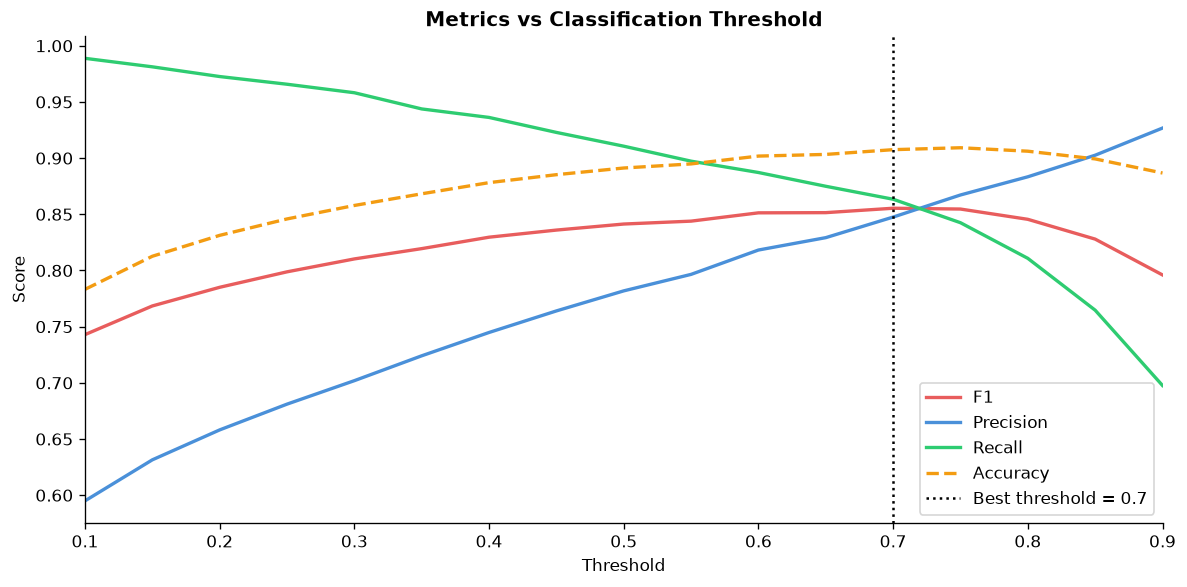


✅ Using threshold: 0.7


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thr_df["threshold"], thr_df["f1"],        label="F1",        lw=2, color="#E85D5D")
ax.plot(thr_df["threshold"], thr_df["precision"],  label="Precision",  lw=2, color="#4A90D9")
ax.plot(thr_df["threshold"], thr_df["recall"],     label="Recall",     lw=2, color="#2ECC71")
ax.plot(thr_df["threshold"], thr_df["accuracy"],   label="Accuracy",   lw=2, color="#F39C12", linestyle="--")
ax.axvline(best_thr, color="black", linestyle=":", label=f"Best threshold = {best_thr}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("Metrics vs Classification Threshold", fontweight="bold")
ax.legend(); ax.set_xlim(0.1, 0.9)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/threshold_tuning.png", bbox_inches="tight")
plt.show()

BEST_THRESHOLD = float(best_thr)
print(f"\n✅ Using threshold: {BEST_THRESHOLD}")


In [17]:
# Save XGBoost model
model_path = os.path.join(MODEL_DIR, "rain_model.json")
model.save_model(model_path)
print(f"✅ Model saved       → {model_path}")

# Save metadata
y_pred_tuned = (y_pred_prob >= BEST_THRESHOLD).astype(int)

meta = {
    "model"            : "XGBoostClassifier",
    "features"         : FEATURES,
    "target"           : TARGET,
    "best_threshold"   : BEST_THRESHOLD,
    "train_rows"       : int(len(X_train)),
    "test_rows"        : int(len(X_test)),
    "metrics": {
        "accuracy"     : round(accuracy_score(y_test, y_pred_tuned), 4),
        "f1_score"     : round(f1_score(y_test, y_pred_tuned, zero_division=0), 4),
        "roc_auc"      : round(roc_auc_score(y_test, y_pred_prob), 4),
        "avg_precision": round(average_precision_score(y_test, y_pred_prob), 4),
    },
    "cv_mean_roc_auc"  : round(float(np.mean(cv_scores["roc_auc"])), 4),
    "cv_std_roc_auc"   : round(float(np.std(cv_scores["roc_auc"])), 4),
    "feature_importance_gain": {
        k: round(v, 4) for k, v in
        sorted(importance_gain.items(), key=lambda x: x[1], reverse=True)
    }
}

meta_path = os.path.join(MODEL_DIR, "model_meta.json")
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
print(f"✅ Metadata saved    → {meta_path}")
print(f"\nFinal Metrics (threshold={BEST_THRESHOLD}):")
for k, v in meta["metrics"].items():
    print(f"  {k:<18}: {v}")


✅ Model saved       → ../models/xgboost\rain_model.json
✅ Metadata saved    → ../models/xgboost\model_meta.json

Final Metrics (threshold=0.7):
  accuracy          : 0.9075
  f1_score          : 0.8554
  roc_auc           : 0.9646
  avg_precision     : 0.9295


In [18]:
def predict_rain(input_dict: dict, threshold: float = BEST_THRESHOLD) -> dict:
    """
    Predict whether it will rain tomorrow given current weather readings.

    Args:
        input_dict : dict with keys matching FEATURES list
        threshold  : classification threshold (default = tuned best threshold)

    Returns:
        dict with rain_tomorrow (bool), probability (float), confidence (str)

    Example:
        predict_rain({
            "temperature"       : 22.5,
            "surface_pressure"  : 1008.0,
            "total_cloud_cover" : 0.6,
            "low_cloud_cover"   : 0.3,
            "medium_cloud_cover": 0.2,
            "high_cloud_cover"  : 0.1,
            "precipitation"     : 0.0,
            "wind_speed"        : 4.5,
            "temp_rolling_6"    : 21.8,
            "temp_lag_1"        : 21.2,
            "temp_lag_24"       : 20.5,
            "month"             : 6,
        })
    """
    row  = pd.DataFrame([{feat: input_dict[feat] for feat in FEATURES}])
    prob = model.predict_proba(row)[0][1]
    will_rain = prob >= threshold

    if prob > 0.75:   confidence = "high (rain likely)"
    elif prob > 0.55: confidence = "medium"
    elif prob < 0.25: confidence = "high (no rain likely)"
    else:             confidence = "low (uncertain)"

    return {
        "rain_tomorrow": bool(will_rain),
        "probability"  : round(float(prob), 4),
        "confidence"   : confidence,
        "threshold_used": threshold,
    }


# ── Demo on 5 test samples ──
print("── Demo Predictions on Test Samples ──")
print(f"{'#':<4} {'Prob':>6} {'Predicted':>12} {'Actual':>10} {'Match':>6}")
print("─" * 45)
for i in range(5):
    sample = X_test.iloc[i].to_dict()
    result = predict_rain(sample)
    actual = int(y_test.iloc[i])
    pred   = "Rain" if result["rain_tomorrow"] else "No Rain"
    act    = "Rain" if actual else "No Rain"
    match  = "✅" if pred == act else "❌"
    print(f"{i+1:<4} {result['probability']:>6.4f} {pred:>12} {act:>10} {match:>6}")


── Demo Predictions on Test Samples ──
#      Prob    Predicted     Actual  Match
─────────────────────────────────────────────
1    0.0311      No Rain    No Rain      ✅
2    0.0405      No Rain    No Rain      ✅
3    0.0273      No Rain    No Rain      ✅
4    0.0280      No Rain    No Rain      ✅
5    0.0105      No Rain    No Rain      ✅


In [19]:
# ── Final summary ──
print("\n" + "═"*50)
print("  TRAINING COMPLETE — SUMMARY")
print("═"*50)
print(f"  Dataset    : {len(df):,} hourly records (1 year)")
print(f"  Train/Test : {len(X_train):,} / {len(X_test):,} rows")
print(f"  CV ROC-AUC : {np.mean(cv_scores['roc_auc']):.4f} ± {np.std(cv_scores['roc_auc']):.4f}")
print(f"  Test ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"  Best Threshold: {BEST_THRESHOLD}")
print(f"  Model saved → {model_path}")
print("═"*50)



══════════════════════════════════════════════════
  TRAINING COMPLETE — SUMMARY
══════════════════════════════════════════════════
  Dataset    : 43,800 hourly records (1 year)
  Train/Test : 35,040 / 8,760 rows
  CV ROC-AUC : 0.9141 ± 0.0554
  Test ROC-AUC: 0.9646
  Best Threshold: 0.7
  Model saved → ../models/xgboost\rain_model.json
══════════════════════════════════════════════════
